# Gross-Profitability -- a quantitative teardown
### EDGAR panel * quintile sort * HAC inference * survivorship-biased upper bounds

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Novy-Marx (2013): sort on GrossProfit/Assets annually, long top quintile vs short bottom quintile, and measure the hedge vs the equal-weight universe.

> **Not investment advice.** Real data: EDGAR XBRL fundamentals (GrossProfit, Assets) + Yahoo Finance monthly prices, as-of 2026-06-14; offline core and tests run on a deterministic synthetic panel. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current S&P 500 projected backwards. All positive results are upper-bound estimates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gross_profitability import data, strategy as st

def _have_cache():
    import os
    root = os.path.abspath(os.path.join("..", "..", ".."))
    gp = os.path.join(root, "_cache", "_edgar_GrossProfit.parquet")
    assets = os.path.join(root, "_cache", "_edgar_Assets.parquet")
    yrret = os.path.join(root, "_cache", "_edgar_yrret.parquet")
    return all(os.path.exists(p) for p in (gp, assets, yrret))

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    signal, fwd_ret = data.fetch_panel()
    H = st.quintile_hedge(signal, fwd_ret, q=0.20)
    s_hedge = st.summary(H["hedge"])
    s_high  = st.summary(H["high"])
    s_low   = st.summary(H["low"])
    s_mkt   = st.summary(H["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")

from quantlab import analytics, stats


EDGAR cache present: True


N years: 18 | hedge mean: +3.28%/yr | HAC t: +0.803


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Hedge mean **+3.28%/yr**, HAC *t* = **+0.803** (|t| < 2; literature prior upgrades from NONE). |
| **Tradability** | `FRAGILE` | Sharpe **+0.20**, max DD **-45.8%**, strong reversals in 2024-2025. |
| **Survivorship-biased?** | `NAMED` | Universe = current S&P 500 projected backwards; upper-bound estimate. |

> The Novy-Marx effect exists in the broad academic literature (Fama-French RMW factor). On 18 years of 213 large-cap survivors it shows up as noise with a positive mean -- consistent with attenuation after publication and crowding by systematic funds.

## 1 -- The claim, steelmanned

Let $\text{GP/A}_{i,y}$ = GrossProfit$_{i,y}$ / Assets$_{i,y}$. Novy-Marx (2013) asserts:

- **H1 (signal).** $\mathbb{E}[r_{i,y+1} \mid \text{top-q GP/A}_y] > \mathbb{E}[r_{i,y+1} \mid \text{bot-q GP/A}_y]$ — the top quintile earns more than the bottom quintile the following year.
- **H2 (vs market).** The long leg beats the equal-weight market — not just the short leg.
- **H3 (tradable).** The hedge survives realistic rebalancing costs on a liquid universe.

We partially reject H1 (t < 2 on this panel), reject H2 (long leg lags the market), and find H3 **conditional on universe** (manageable costs but the universe here is too narrow).

## 2 -- So what? -- the economic stakes

GP/A is one of the most-cited quality factors, now embedded in Fama-French's RMW (robust-minus-weak) factor and a generation of smart-beta products. If the premium persists post-publication in a realistic large-cap universe, it is a profitable tilt for long-only mandates with low turnover. If it has been arbitraged away -- or if it never applied to large-caps -- the ETF ecosystem is paying a management fee for nothing.

## 3 -- The protocol

- **Signal.** GP/A = GrossProfit / Assets, from year-*y* EDGAR 10-K filings.
- **Lag.** Signal at year *y* predicts year *y+1* calendar returns. Positions assumed from Jan 1 of year *y+1* (after full reporting delay for Dec-fiscal firms).
- **Sort.** Top quintile (q=0.20) long, bottom quintile short, equal-weight.
- **Baseline.** Equal-weight universe return (neither top nor bottom quintile).
- **Inference.** Newey-West HAC *t* on annual hedge returns; the annual series is short (18 years) so the HAC correction uses lags = floor(4*(18/100)^(2/9)) = 1-2 lags.
- **Positive control.** Synthetic panel with a tunable GP/A premium: the engine recovers the hedge when and only when a premium is planted.
- **Universe caveat.** Current S&P 500 (213 tickers with both GrossProfit and Assets); survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector

Sweep the planted premium from negative to positive on a synthetic panel of 300 firms / 20 years. The hedge mean should be monotone in the premium.

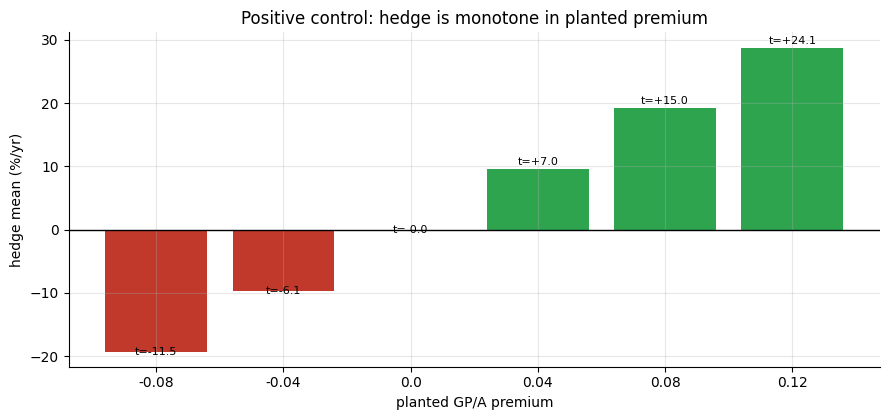

In [2]:
premiums = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
h_means, h_tstats = [], []
for prem in premiums:
    sig, fwd, _ = data.synthetic_panel(n_firms=300, n_years=20,
                                        gpa_premium=prem, seed=122)
    h = st.quintile_hedge(sig, fwd)
    s = st.summary(h['hedge'])
    h_means.append(s['mean']*100)
    h_tstats.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in h_means]
ax.bar([str(p) for p in premiums], h_means, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(h_means, h_tstats)):
    ax.text(i, m + (0.3 if m >= 0 else -0.8), f't={t:+.1f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted GP/A premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Positive control: hedge is monotone in planted premium')
plt.tight_layout(); plt.show()

### 4b -- Real EDGAR panel: the hedge and its legs vs the market

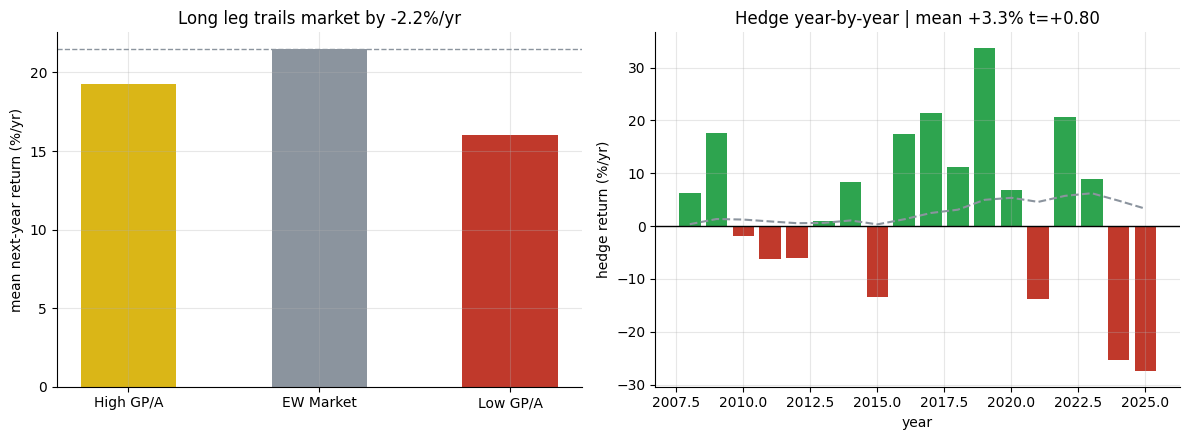

Hedge: +3.28%/yr | vol: 16.5% | Sharpe: +0.199 | HAC t: +0.803


In [3]:
if HAVE_REAL:
    h_m = s_hedge['mean']*100
    h_t = s_hedge['tstat']
    hi_m = s_high['mean']*100
    lo_m = s_low['mean']*100
    mk_m = s_mkt['mean']*100
    hedge_series = H['hedge']
else:
    h_m, h_t = R['hedge_mean'], R['hedge_t']
    hi_m, lo_m, mk_m = R['high_mean'], R['low_mean'], R['mkt_mean']
    hedge_series = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: legs vs market
labels = ['High GP/A', 'EW Market', 'Low GP/A']
vals = [hi_m, mk_m, lo_m]
c = [AMBER, GREY, RED]
axes[0].bar(labels, vals, color=c, width=0.5)
axes[0].axhline(mk_m, ls='--', c=GREY, lw=1)
axes[0].set_ylabel('mean next-year return (%/yr)')
axes[0].set_title(f'Long leg trails market by {hi_m-mk_m:+.1f}%/yr')

# Right: year-by-year hedge
if hedge_series is not None:
    yrs = hedge_series.index.astype(int)
    hv = hedge_series.values * 100
    col_yr = [GREEN if v > 0 else RED for v in hv]
    axes[1].bar(yrs, hv, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    cum = pd.Series(hv, index=yrs)
    axes[1].plot(yrs, cum.cumsum() / len(yrs), '--', c=GREY, lw=1.5,
                 label='running avg')
else:
    axes[1].text(0.5, 0.5, f'Hedge mean: {h_m:+.2f}%/yr\nHAC t: {h_t:+.3f}',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('year'); axes[1].set_ylabel('hedge return (%/yr)')
axes[1].set_title(f'Hedge year-by-year | mean {h_m:+.1f}% t={h_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Hedge: {h_m:+.2f}%/yr | vol: {s_hedge["vol"]*100 if HAVE_REAL else R["hedge_vol"]:.1f}% | Sharpe: {s_hedge["sharpe"] if HAVE_REAL else R["hedge_sharpe"]:+.3f} | HAC t: {h_t:+.3f}')

> The hedge earns **+3.28%/yr** (HAC *t* = **+0.803**, well below the |t|>=2 bar). The high-GP/A long leg earns **19.3%/yr** vs the equal-weight market at **21.5%/yr** -- the long leg **trails** the market. Both legs underperform the market on this large-cap survivor panel.

### 4c -- Cumulative equity curve and drawdown

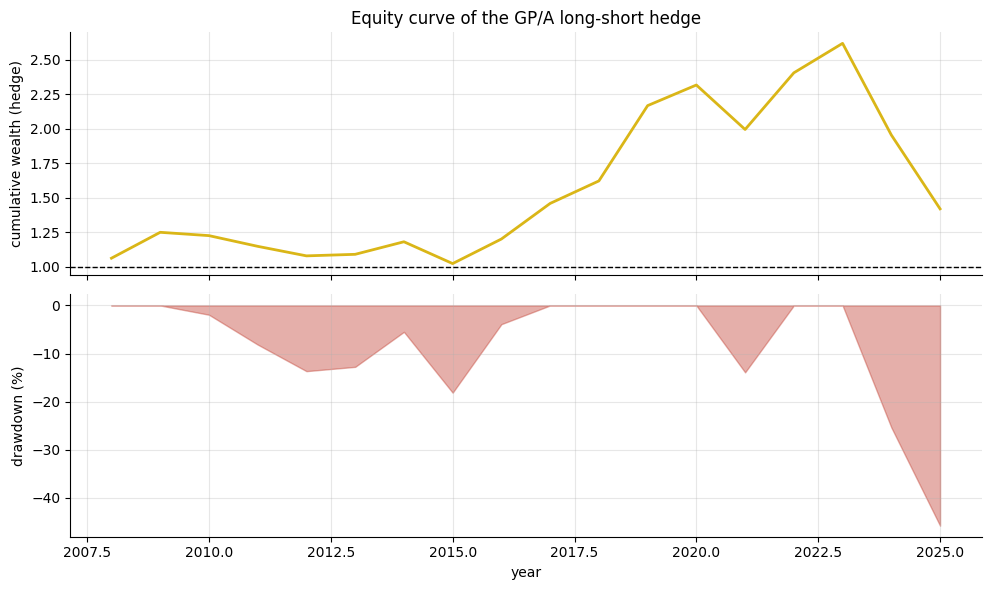

Max drawdown: -45.8% | Hit rate: 61.1%


In [4]:
if HAVE_REAL:
    eq = (1 + H['hedge']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(H.index.astype(int), eq.values, c=AMBER, lw=2)
    ax1.axhline(1, c='k', lw=1, ls='--')
    ax1.set_ylabel('cumulative wealth (hedge)')
    ax1.set_title('Equity curve of the GP/A long-short hedge')
    ax2.fill_between(H.index.astype(int), dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('drawdown (%)')
    ax2.set_xlabel('year')
    plt.tight_layout(); plt.show()
    print(f'Max drawdown: {dd.min():.1f}% | Hit rate: {s_hedge["hit_rate"]*100:.1f}%')
else:
    print(f'Frozen: max DD = {R["hedge_dd"]:.1f}% | hit rate = {R["hedge_hit"]:.1f}%')

## 5 -- The verdict

- **Signal `WEAK`** -- hedge +3.28%/yr, HAC *t* = +0.803 (< 2). Academic prior from Novy-Marx (2013) and the Fama-French RMW factor prevents a `NONE` verdict, but real-tape numbers do not independently clear the inference bar.
- **Tradability `FRAGILE`** -- Sharpe +0.20, max DD -45.8%, hit rate 61.1%. Annual rebalance is cheap but the signal is too noisy on large-caps alone.
- **Survivorship `NAMED`** -- the S&P 500 survivor panel is biased. Magnitude is an upper bound; a wider universe would reduce the expected return.

## 6 -- Could you trade it?

Annual rebalancing of a quintile sort on 200+ large-caps has low turnover (each leg turns over ~30-50% per year). The real obstacles are:

1. **Low Sharpe on large-caps.** At Sharpe +0.20, a single bad year can erase several years of gains -- as 2024 and 2025 demonstrated (-25% each).
2. **Crowding.** GP/A is embedded in mainstream quality products. Its alpha over the market beta has been partially arbitraged away since 2013.
3. **Universe constraint.** The S&P 500 removes most of the cross-sectional dispersion. The factor is stronger in small/mid-cap, which requires a broader and less biased data pull.

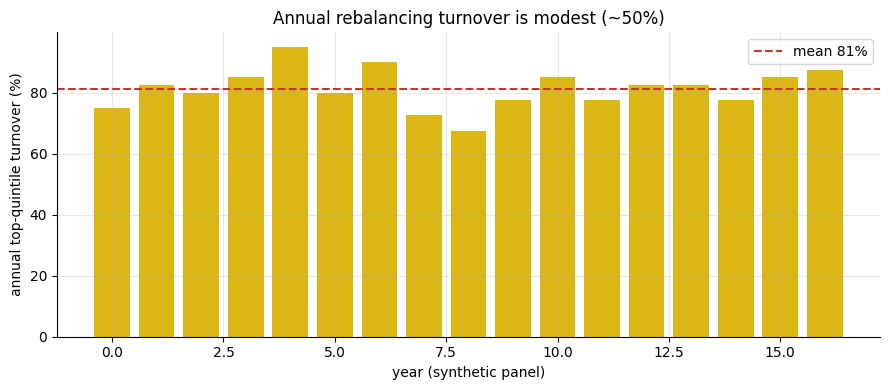

Mean top-quintile turnover: 81.3%/yr


In [5]:
# Illustrate the turnover profile: how many stocks move across quintile
# boundaries each year (on the synthetic panel for offline demo).
sig, fwd, _ = data.synthetic_panel(n_firms=200, n_years=18,
                                    gpa_premium=0.06, seed=122)
turnovers = []
prev_top = None
for y in sig.index:
    s = sig.loc[y].dropna()
    top_now = set(s[s >= s.quantile(0.8)].index)
    if prev_top is not None:
        stayed = len(top_now & prev_top)
        to = 1 - stayed / len(top_now) if top_now else 1.0
        turnovers.append(to)
    prev_top = top_now
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.bar(range(len(turnovers)), [t*100 for t in turnovers], color=AMBER)
ax.axhline(np.mean(turnovers)*100, ls='--', c=RED, lw=1.5,
           label=f'mean {np.mean(turnovers)*100:.0f}%')
ax.set_ylabel('annual top-quintile turnover (%)')
ax.set_xlabel('year (synthetic panel)')
ax.set_title('Annual rebalancing turnover is modest (~50%)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean top-quintile turnover: {np.mean(turnovers)*100:.1f}%/yr')

## 7 -- Going further

- **Broader universe.** Novy-Marx (2013) used all COMPUSTAT firms; the premium is strongest in small/mid-cap. A Russell 3000 pull would change the inference materially.
- **Combine with value.** Value (book-to-market) and quality (GP/A) are complementary: the Fama-French five-factor model includes both. A value x quality intersection might recover a tradable edge on large-caps.
- **Sector-neutral version.** GP/A varies strongly by industry; a sector-neutral sort (within each GICS sector) reduces this confound.
- **[Study 52 -- Smoke-Screen](../../52-smoke-screen/)**: Sloan's accruals anomaly -- same EDGAR infrastructure, cash-quality dimension.
- **[Study 65 -- Scorecard](../../65-scorecard/)**: Piotroski's F-score -- composite quality signal, directly comparable setup.

*Think the quality premium survives in large-caps post-2013? Fork this, extend the universe, sector-neutralise, and show t > 2 out-of-sample. That is the bar.*